## General Setup

In [80]:
import sys
from pathlib import Path

# notebooks/ -> repo root
REPO_ROOT = Path.cwd().resolve()
print(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))
sys.path.append("..")

/Users/tzhang04/Desktop/active-passive-alternations/notebooks


In [81]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import normaltest, ttest_rel, wilcoxon
from sklearn.preprocessing import StandardScaler
from IPython.display import Markdown, display
from src.uid import *

In [82]:
import conllu
from conllu import Token, parse, parse_tree
from pyinflect import getAllInflections, getInflection
from src.utils import *
from src.units.word import *
from src.units.sentence import *

## Test Feature Extraction

### Load documents

In [17]:
ud_path = "../data/en_gum-ud-dev.conllu"
docs = iter_counterfactual_docs(ud_path)

In [18]:
# look for sentences with key
doc = [doc for doc in docs if doc[0] == 'cf::GUM_conversation_grounded::22::a>p'][0]
key_sents = []
for doc in docs:
    for sent in doc[2]:
        if " her " in sent.text:
            # print("Found it")
            key_sents.append(sent)

In [19]:
# [sent.text for sent in key_sents]

In [20]:
# key_sents[0]

In [21]:
nlp = stanza.MultilingualPipeline()

2026-04-05 14:40:38 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2026-04-05 14:40:39 INFO: Downloaded file to /Users/tzhang04/stanza_resources/resources.json
2026-04-05 14:40:39 INFO: Loading these models for language: multilingual ():
| Processor | Package |
-----------------------
| langid    | ud      |

2026-04-05 14:40:39 INFO: Using device: cpu
2026-04-05 14:40:39 INFO: Loading: langid
2026-04-05 14:40:39 INFO: Done loading processors!


In [23]:
# nlp("My mom picked up a dog in the park.")

In [6]:
doc_id, sents, doc = docs[0]

In [7]:
for doc_id, sents, doc in docs:
    for sent in doc:
        try:
            active_sent = ActiveSentence(sent)
        except:
            continue

In [8]:
active_sent.text

'If you wash your overalls alone or in a light load, use about half the detergent called for and less water.'

In [9]:
active_sent.active_subject_word

{'id': 2,
 'form': 'you',
 'lemma': 'you',
 'upos': 'PRON',
 'xpos': 'PRP',
 'feats': {'Case': 'Nom', 'Number': 'Sing', 'Person': '2', 'PronType': 'Prs'},
 'head': 3,
 'deprel': 'nsubj',
 'deps': [('nsubj', 3)],
 'misc': {'Entity': '(3-person-giv:inact-nnsnn-cf1-1-ana)'},
 'inflection': 'PRP',
 'children': []}

In [10]:
tok, model, device = load_lm('distilgpt2', device='mps')
unigram = UnigramLM(tok)
unigram.fit("\n".join(["\n".join(doc[1]) for doc in docs]), uid_unit='word')

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 2572.36it/s, Materializing param=transformer.wte.weight]            
GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Token indices sequence length is longer than the specified maximum sequence length for this model (487324 > 1024). Running this sequence through the model will result in indexing errors


In [11]:
result = ling_features(active_sent, tok, unigram, uid_unit='word')

In [12]:
unigram.model.get('you', 0)

0.01065558639014376

In [13]:
unigram('you')

(array([0.01065559]), np.float64(0.01065558639014376))

In [15]:
result

{'agent': [{'id': 2,
   'form': 'you',
   'lemma': 'you',
   'upos': 'PRON',
   'xpos': 'PRP',
   'feats': {'Case': 'Nom',
    'Number': 'Sing',
    'Person': '2',
    'PronType': 'Prs'},
   'head': 3,
   'deprel': 'nsubj',
   'deps': [('nsubj', 3)],
   'misc': {'Entity': '(3-person-giv:inact-nnsnn-cf1-1-ana)'},
   'inflection': 'PRP',
   'children': []}],
 'agent_len': 1,
 'agent_unigram_prob': np.float64(0.01065558639014376),
 'agent_is_pronoun': True,
 'agent_is_plural': False,
 'patient': [{'id': 4,
   'form': 'your',
   'lemma': 'your',
   'upos': 'PRON',
   'xpos': 'PRP$',
   'feats': {'Case': 'Gen',
    'Number': 'Sing',
    'Person': '2',
    'Poss': 'Yes',
    'PronType': 'Prs'},
   'head': 5,
   'deprel': 'nmod:poss',
   'deps': [('nmod:poss', 5)],
   'misc': {'Entity': '(1-object-giv:inact-sssss-cf2-2-coref(3-person-giv:act-nnsnn-cf1-1-ana)'},
   'inflection': 'PRP$',
   'children': []},
  {'id': 5,
   'form': 'overalls',
   'lemma': 'overall',
   'upos': 'NOUN',
   'xpos': 

In [13]:
# Animacy from WordNet
import nltk
nltk.download("wordnet")
from nltk.corpus import wordnet as wn

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/tzhang04/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [14]:
syn = wn.synsets("we", pos=wn.NOUN)
i = 0
syn[i], syn[i].lexname(), syn[i].definition()

IndexError: list index out of range

In [16]:
# Get synsets for the verb 'run'
for synset in wn.synsets('run', pos=wn.VERB):
    print(synset.name(), ":", synset.definition())

run.v.01 : move fast by using one's feet, with one foot off the ground at any given time
scat.v.01 : flee; take to one's heels; cut and run
run.v.03 : stretch out over a distance, space, time, or scope; run or extend between two points or beyond a certain point
operate.v.01 : direct or control; projects, businesses, etc.
run.v.05 : have a particular form
run.v.06 : move along, of liquids
function.v.01 : perform as expected when applied
range.v.01 : change or be different within limits
campaign.v.01 : run, stand, or compete for an office or a position
play.v.18 : cause to emit recorded audio or video
run.v.11 : move about freely and without restraint, or act as if running around in an uncontrolled way
tend.v.01 : have a tendency or disposition to do or be something; be inclined
run.v.13 : be operating, running or functioning
run.v.14 : change from one state to another
run.v.15 : cause to perform
run.v.16 : be affected by; be subjected to
prevail.v.03 : continue to exist
run.v.18 : occur

In [90]:
is_animate("we")

False

### Check feature extraction outputs

In [24]:
out = pd.read_csv("../temp/cf_word_sentence_uid_chkpt.csv")

In [25]:
ling_features = ["doc_id", "sent_idx"]
for name in ['agent', 'patient']:
    ling_features.extend([
        f"{name}",
        f"{name}_len", 
        f"{name}_unigram_logprob",
        f"{name}_is_pronoun",
        f"{name}_is_plural",
        f"{name}_is_animate",
        f"{name}_is_definite",])

In [26]:
ling_feat_out = out[['sentence'] + ling_features]

In [27]:
ling_feat_out[ling_feat_out['agent_is_definite']].head()

,sentence,doc_id,sent_idx,agent,agent_len,agent_unigram_logprob,agent_is_pronoun,agent_is_plural,agent_is_animate,agent_is_definite,patient,patient_len,patient_unigram_logprob,patient_is_pronoun,patient_is_plural,patient_is_animate,patient_is_definite
8,Such a scenario may be found in different situ...,f::GUM_academic_exposure::-1::og,6,one,1,-6.257701,True,False,True,True,a language,2,-12.056551,False,False,False,False
9,Such a scenario may be found in different situ...,f::GUM_academic_exposure::-1::og,6,one,1,-6.257701,True,False,True,True,a language,2,-12.056551,False,False,False,False
10,Such a scenario may be found in different situ...,f::GUM_academic_exposure::-1::og,6,one,1,-6.257701,True,False,True,True,a language,2,-12.056551,False,False,False,False
11,Such a scenario may be found in different situ...,f::GUM_academic_exposure::-1::og,6,one,1,-6.257701,True,False,True,True,a language,2,-12.056551,False,False,False,False
12,Such a scenario may be found in different situ...,f::GUM_academic_exposure::-1::og,6,one,1,-6.257701,True,False,True,True,a language,2,-12.056551,False,False,False,False


In [28]:
doc = [doc for doc in docs if doc[0] == 'f::GUM_academic_exposure::-1::og'][0]
is_definite(doc[2][13][18])

False

In [29]:
is_definite(doc[2][13].active_subject_word)

False

## Model Experiments

### Setup

#### Imports

In [88]:
# Import
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, roc_auc_score
import statsmodels.api as sm
SEED = 169

#### Utils

In [89]:
# Utils
def extract_sents_of_interest(doc_sents: pd.DataFrame):
    converted_indices = doc_sents['conv_idx'].unique()
    sents_of_interest = []
    for i, sent in doc_sents.iterrows():
        if ((sent['sent_idx'] in converted_indices)
            and 
            (sent['conv_idx'] in [sent['sent_idx'], -1])):
            sents_of_interest.append(sent)
    return pd.DataFrame(sents_of_interest)

def check_passive(f_cf_pair: pd.DataFrame):
    conversion = f_cf_pair['conversion'].unique()
    if 'a>p' in conversion:
        return f_cf_pair.assign(passive=[False if fact else True for fact in f_cf_pair['factual']])
    elif 'p>a' in conversion:
        return f_cf_pair.assign(passive=[True if fact else False for fact in f_cf_pair['factual']])
    
def check_conversion(row):
    mapping = {
        "p>a": "P to A",
        "a>p": "A to P"
    }
    if row['conversion'] != 'og':
        return mapping[row['conversion']]
    if row['passive']:
        return 'P to A'
    return 'A to P'

def perm_test(data, 
              label_column, 
              value_column, 
              n_permutations, 
              agg_fn=np.mean, 
              test_stat=lambda a, b: np.abs(a - b),
              compare_fn=lambda sim, obs: sim >= obs,
              ):
    value_a, value_b = data[label_column].unique()
    print("Labels in order: ", value_a, value_b)
    obs_a = agg_fn(data.loc[data[label_column] == value_a, value_column])
    obs_b = agg_fn(data.loc[data[label_column] == value_b, value_column])
    obs_stat = test_stat(obs_a, obs_b)
    
    sim_stats = []
    for _ in range(n_permutations):
        sim_labels = np.random.permutation(data[label_column])
        sim_a = agg_fn(data.loc[sim_labels == value_a, value_column])
        sim_b = agg_fn(data.loc[sim_labels == value_b, value_column])
        sim_stat = test_stat(sim_a, sim_b)
        sim_stats.append(sim_stat)
    sim_stats = np.array(sim_stats)
    return obs_stat, sim_stats, (compare_fn(sim_stats, obs_stat)).mean()

def evaluate_model(model, X, y, plot=True):
    y_score = model.predict(X)
    y_pred = y_score > 0.5
    cm = confusion_matrix(y, y_pred)
    # fpr, tpr, thresh = roc_curve(y, y_score)
    roc_auc = roc_auc_score(y, y_score)
    acc = accuracy_score(y, y_pred)
    act_acc = cm[0][0] / (cm[0][0] + cm[0][1])
    pass_acc = cm[1][1] / (cm[1][0] + cm[1][1])
    macro_acc = (act_acc + pass_acc) / 2

    print("Accuracy: %.4f" % acc)
    print("Macro Acc: %.4f" % macro_acc)
    print("ROC-AUC: %.4f" % roc_auc)
    if plot:
        sns.heatmap(cm, annot=True)
        plt.ylabel("Actual")
        plt.xlabel("Predicted")
        plt.title("Confusion Matrix")
    
    return cm, roc_auc, acc

def create_legend(cmap):
    handles = []
    for label, color in cmap.items():
        patch = mpatches.Patch(color=color, label=label)
        handles.append(patch)
    return plt.legend(handles=handles)

def cp_plot(data, feature, model, grid_size=100):
    feature_range = None
    all_cp_predictions = []
    for i in range(data.shape[0]):
        observation = data.iloc[[i]]
        feature_range, cp_pred = cp_plot_single(data, 
                                                feature, 
                                                observation, 
                                                model, 
                                                grid_size=grid_size)
        all_cp_predictions.append(cp_pred)
    all_cp_predictions = np.vstack(all_cp_predictions)
    mean_cp_predictions = all_cp_predictions.mean(axis=0)
    return feature_range, mean_cp_predictions

def cp_plot_single(data, feature, observation, model, grid_size=100):
    feature_min = data[feature].min()
    feature_max = data[feature].max()
    feature_range = np.arange(feature_min, feature_max,
                              (feature_max - feature_min) / grid_size)
    cp_observations = [observation.copy(deep=True).assign(**{feature:feat_val}) 
                       for feat_val in feature_range]
    cp_predictions = model.predict_proba(pd.concat(cp_observations))[:, 1]
        
    return feature_range, cp_predictions
    

#### Plotting

In [90]:
# Seaborn defaults
bg_color = "#FAF9F6"
grid_color = "#E5E4E2"
sns.set(rc={
    'axes.facecolor':bg_color, 
    'figure.facecolor':bg_color,
    'grid.color': grid_color,
    'axes.edgecolor': grid_color,
    'lines.markeredgecolor': grid_color,
    'scatter.edgecolors': grid_color,
})
sns.set_palette("Set2")
# Font
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": "Times",
})

In [91]:
# Define features
util_features = [
        'doc_id',
        'sent_idx',
        'context',
        'factual',
        'conversion'
]

ling_features = []
for name in ['agent', 'patient']:
    ling_features.extend([
        # f"{name}",
        f"{name}_len", 
        f"{name}_unigram_logprob",
        f"{name}_is_pronoun",
        f"{name}_is_plural",
        f"{name}_is_animate",
        f"{name}_is_definite",])

ling_features_formatted = [
        "Agt Len", 
        "Agt Log Prob",
        "Agt Pronom",
        "Agt Plural",
        "Agt Animate",
        "Agt Definite",
        "Pnt Len", 
        "Pnt Log Prob",
        "Pnt Pronom",
        "Pnt Plural",
        "Pnt Animate",
        "Pnt Definite",
]

uid_features = [
        'uid_std',
        # 'uid_mad',
        'uid_pwd',
        # 'uid_range',
        # 'uid_cv'
]

uid_features_formatted = [
        'Surp. STD',
        # 'Surp. MAD',
        'Local Var.',
        # 'Surp. Range',
        # 'Surp. CV', # Coeff. of Variation
]

surp_features = [
        # 'surp_mean',
        'surp_slor'
]

surp_features_formatted = [
        # 'Mean Surp.',
        '-SLOR',
]
format_map = {'const': 'Intercept'}
format_map.update(dict(zip(
        ling_features, ling_features_formatted
)))
format_map.update(dict(zip(
        uid_features, uid_features_formatted
)))
format_map.update(dict(zip(
        surp_features, surp_features_formatted
)))

# Colormaps
## Feature cmap
feature_cmap = {'const': "#3D3B40"}
ling_color = "#11235A"
uid_color = "#8f97cf"
surp_color = "#ab9ab5"
feature_cmap.update(dict(zip(
    ling_features, [ling_color] * len(ling_features)
    )))
feature_cmap.update(dict(zip(
    uid_features, [uid_color] * len(uid_features)
    )))
feature_cmap.update(dict(zip(
    surp_features, [surp_color] * len(surp_features)
    )))
feature_legend_cmap = {
    "Baseline Features": ling_color,
    "UID Features": uid_color,
    "Surprisal Features": surp_color
}

## Passive cmap
passive_cmap = {
    True: "tomato",
    False: "steelblue",
    "Both": "#FFF8DE",
}
passive_cmap.update({
        "Passive": passive_cmap[True],
        "Active": passive_cmap[False],
        "P to A": passive_cmap[True],
        "A to P": passive_cmap[False],
})

#### Data setup

In [92]:
data_path = "../temp/cf_word_sentence_uid_chkpt_pile.csv"
data_path = Path(data_path)
uid_df = pd.read_csv(data_path)
uid_df.shape

(223944, 32)

In [93]:
_, uid_unit, uid_level = data_path.stem.split("_")[:3]
context_lvls = ['document']
plot_suffix = f"_{uid_unit}_{uid_level}"

In [94]:
uid_df[['factual', 'doc_name', 'conv_idx', 'conversion']] = uid_df['doc_id'].str.split("::", expand=True)
uid_df['conv_idx'] = uid_df['conv_idx'].astype(int)
uid_df['surp_slor'] *= -1

In [95]:
uid_df.columns

Index(['Unnamed: 0', 'doc_id', 'sent_idx', 'context', 'sentence', 'tokens',
       'units', 'raw_surps', 'raw_uni_surps', 'surp_mean', 'surp_slor',
       'uid_std', 'uid_mad', 'uid_pwd', 'uid_range', 'uid_cv', 'uid_slope',
       'uid_len', 'agent', 'agent_len', 'agent_unigram_logprob',
       'agent_is_pronoun', 'agent_is_plural', 'agent_is_animate',
       'agent_is_definite', 'patient', 'patient_len',
       'patient_unigram_logprob', 'patient_is_pronoun', 'patient_is_plural',
       'patient_is_animate', 'patient_is_definite', 'factual', 'doc_name',
       'conv_idx', 'conversion'],
      dtype='str')

In [96]:
sents_of_interest = uid_df.groupby("doc_name").apply(extract_sents_of_interest).reset_index().drop(columns="level_1")
sents_of_interest.shape

(223328, 36)

In [97]:
cf_comparison = sents_of_interest[sents_of_interest['context'].isin(context_lvls)].drop(columns=['raw_surps', 'raw_uni_surps'])
cf_comparison['factual'] = cf_comparison['factual'] == 'f'
cf_comparison = cf_comparison.groupby(['doc_id', 'sent_idx', 'context']).first().sort_values(by=['doc_name', 'sent_idx']).reset_index()
cf_comparison = cf_comparison.groupby(['doc_name', 'sent_idx']).filter(lambda g: g.shape[0] >= len(context_lvls) * 2)
cf_comparison = cf_comparison.groupby(['doc_name', 'sent_idx']).apply(check_passive).reset_index()
cf_comparison['conversion'] = cf_comparison.apply(check_conversion, axis=1)
# print(((cf_comparison['patient_unigram_logprob'] != -np.inf) & (cf_comparison['agent_unigram_logprob'] != -np.inf)).mean())
cf_comparison = cf_comparison[((cf_comparison['patient_unigram_logprob'] != -np.inf) & (cf_comparison['agent_unigram_logprob'] != -np.inf))]
print(cf_comparison.shape)
cf_comparison.head()

(27702, 36)


,doc_name,sent_idx,level_2,doc_id,context,Unnamed: 0,sentence,tokens,units,surp_mean,...,patient_len,patient_unigram_logprob,patient_is_pronoun,patient_is_plural,patient_is_animate,patient_is_definite,factual,conv_idx,conversion,passive
0,wik_eng_wikipedia_1.00001_x00002,4.0,0,cf::wik_eng_wikipedia_1.00001_x00002::4::a>p,document,51.0,A bachelor's degree in Business Administration...,"['A', 'Ġbachelor', ""'s"", 'Ġdegree', 'Ġin', 'ĠB...","['A', ""Ġbachelor's"", 'Ġdegree', 'Ġin', 'ĠBusin...",10.067887,...,7.0,-8.882359,False,False,False,True,False,4.0,A to P,True
1,wik_eng_wikipedia_1.00001_x00002,4.0,1,f::wik_eng_wikipedia_1.00001_x00002::-1::og,document,3.0,Jamila holds a bachelor's degree in Business A...,"['Jam', 'ila', 'Ġholds', 'Ġa', 'Ġbachelor', ""'...","['Jamila', 'Ġholds', 'Ġa', ""Ġbachelor's"", 'Ġde...",9.105185,...,7.0,-8.882359,False,False,False,True,True,-1.0,A to P,False
2,wik_eng_wikipedia_1.00001_x00002,8.0,2,cf::wik_eng_wikipedia_1.00001_x00002::8::a>p,document,59.0,"J Mobile Laundry Services, a door to door laun...","['J', 'ĠMobile', 'ĠL', 'aund', 'ry', 'ĠService...","['J', 'ĠMobile', 'ĠLaundry', 'ĠServices,', 'Ġa...",8.258878,...,18.0,-8.754797,False,True,False,False,False,8.0,A to P,True
3,wik_eng_wikipedia_1.00001_x00002,8.0,3,f::wik_eng_wikipedia_1.00001_x00002::-1::og,document,11.0,"She founded J Mobile Laundry Services, a door ...","['She', 'Ġfounded', 'ĠJ', 'ĠMobile', 'ĠL', 'au...","['She', 'Ġfounded', 'ĠJ', 'ĠMobile', 'ĠLaundry...",7.813893,...,18.0,-8.754797,False,True,False,False,True,-1.0,A to P,False
4,wik_eng_wikipedia_1.00001_x00002,9.0,4,cf::wik_eng_wikipedia_1.00001_x00002::9::a>p,document,67.0,They are trained by her in entrepreneurship sk...,"['They', 'Ġare', 'Ġtrained', 'Ġby', 'Ġher', 'Ġ...","['They', 'Ġare', 'Ġtrained', 'Ġby', 'Ġher', 'Ġ...",7.148259,...,1.0,-7.958208,True,True,True,True,False,9.0,A to P,True


In [98]:
# Compare factuals to cfactuals (should be even)
print("N factual docs:", len(cf_comparison['doc_name'].unique()))
cf_comparison['factual'].value_counts()

N factual docs: 2351


factual
False    13851
True     13851
Name: count, dtype: int64

In [99]:
# Compare conversion directions (P>A should be a lot less)
print("Num. sentence pairs:", end=" ")
print((cf_comparison['factual'] & (cf_comparison['context']==context_lvls[0])).sum())
cf_comparison.loc[cf_comparison['factual']
                  & (cf_comparison['context']==context_lvls[0]),
                  'conversion'].value_counts()

Num. sentence pairs: 13851


conversion
A to P    11799
P to A     2052
Name: count, dtype: int64

In [100]:
# Standardize metrics
standard_scaler = StandardScaler()
feats_to_standardize = (['patient_len',
                         'agent_len',
                         'patient_unigram_logprob',
                         'agent_unigram_logprob']
                        + uid_features
                        + surp_features)
cf_comparison[feats_to_standardize] = standard_scaler.fit_transform(cf_comparison[feats_to_standardize])

In [101]:
# take pairwise differences, but *Active - Passive*
get_diff = lambda s: s.diff().iloc[1]
pass_through = lambda s: s.iloc[0]
agg_map = dict(zip(uid_features + surp_features, [get_diff] * len(uid_features + surp_features)))
agg_map.update(dict(zip(ling_features, [pass_through] * len(ling_features))))
agg_map.update({
    'conversion': lambda s: 'A to P' if 'A to P' in s.unique() else 'P to A',
    # 'passive': lambda s: s.iloc[0],
})
pw_diffs = (cf_comparison
            .sort_values(by='passive', ascending=False) # Always Active - Passive
            .groupby(['doc_name','sent_idx', 'context'])
            [uid_features + surp_features + ling_features + ['conversion']]
            .aggregate(
                agg_map
                )
            .reset_index())
pw_diffs = pw_diffs[pw_diffs['surp_slor'] != 0]
pw_diffs['passive'] = pw_diffs['conversion'] == 'P to A'
pw_diffs = pw_diffs.reset_index(drop=True)

In [102]:
# Within pw_diffs now: features for each sentence, including the difference
# (Active - Passive) in UID metrics, and target (passive).
pw_diffs.head()

,doc_name,sent_idx,context,uid_std,uid_pwd,surp_slor,agent_len,agent_unigram_logprob,agent_is_pronoun,agent_is_plural,agent_is_animate,agent_is_definite,patient_len,patient_unigram_logprob,patient_is_pronoun,patient_is_plural,patient_is_animate,patient_is_definite,conversion,passive
0,wik_eng_wikipedia_1.00001_x00002,4.0,document,0.244852,0.628158,-1.003585,-0.470004,-1.353361,False,False,False,False,0.106211,0.408466,False,False,False,True,A to P,False
1,wik_eng_wikipedia_1.00001_x00002,8.0,document,-0.496263,-0.117588,-0.439700,-0.470004,1.090484,True,False,True,True,1.455311,0.468153,False,True,False,False,A to P,False
2,wik_eng_wikipedia_1.00001_x00002,9.0,document,-0.704772,-0.576847,-0.323137,-0.470004,1.090484,True,False,True,True,-0.629661,0.840888,True,True,True,True,A to P,False
3,wik_eng_wikipedia_1.00001_x00002,11.0,document,0.137922,0.090461,-0.320824,-0.470004,1.090484,True,False,True,True,-0.384371,0.305643,False,False,False,False,A to P,False
4,wik_eng_wikipedia_1.00001_x00002,12.0,document,0.065454,-0.079410,-0.390841,-0.470004,1.090484,True,False,True,True,-0.261725,0.488441,False,False,False,False,A to P,False


### Modeling

#### Define train and test datasets

In [139]:
# define features, target, and naive baseline
X = pw_diffs[[]
    + ling_features
    + uid_features
    + surp_features
    ]
y = pw_diffs['passive']

# bootstrap to resolve class imbalance
if False:
    indices = pd.Series(X.index)
    n = X.shape[0]
    sampled_passive = indices[y].sample(n // 2, replace=True)
    sampled_active = indices[~y].sample(n // 2, replace=True)
    X = pd.concat([X.iloc[sampled_passive], X.iloc[sampled_active]])
    y = pd.concat([y.iloc[sampled_passive], y.iloc[sampled_active]])
    
# resample to resolve class imbalance
if True:
    indices = pd.Series(X.index)
    n = min(y.sum(), (~y).sum())
    sampled_passive = indices[y]
    sampled_active = indices[~y].sample(n, replace=False)
    X = pd.concat([X.iloc[sampled_passive], X.iloc[sampled_active]]).reset_index(drop=True)
    y = pd.concat([y.iloc[sampled_passive], y.iloc[sampled_active]]).reset_index(drop=True)
    
X = sm.add_constant(X, has_constant='add')
X = X.astype(np.float64)
y = y.astype(np.float64)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    shuffle=True, stratify=y,
                                                    random_state=SEED)
naive_baseline_accuracy = max(y.mean(), (1 - y).mean())
X.shape, naive_baseline_accuracy

((4018, 16), np.float64(0.5))

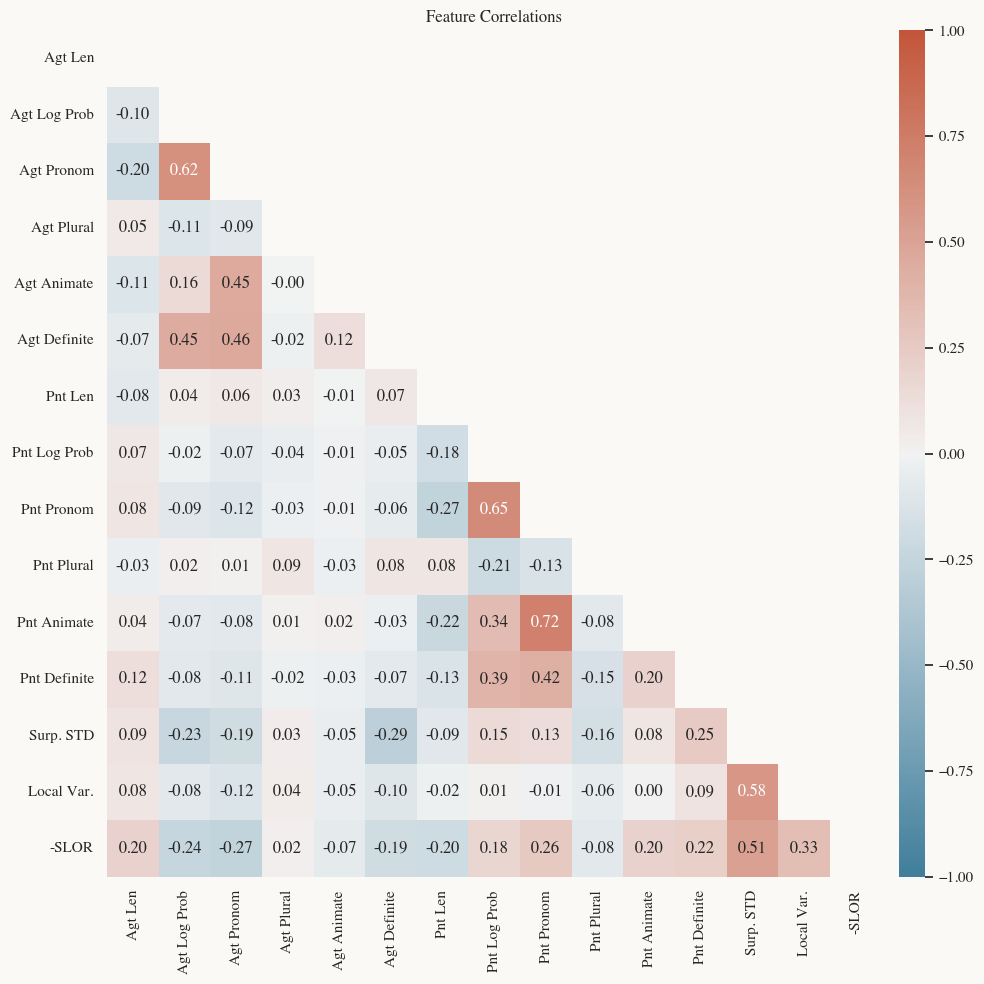

In [140]:
fig, axs = plt.subplots(1, 2, figsize=(10, 10), width_ratios=[30, 1])
cmap = sns.diverging_palette(230, 20, as_cmap=True)

data = X.drop(columns=['const'])
data.columns = [format_map[col] for col in data.columns]
data = data.corr()
mask = np.triu(np.ones_like(data, dtype=bool))
sns.heatmap(data, mask=mask,
            annot=True, fmt=".2f", ax=axs[0], cbar_ax=axs[-1], cmap=cmap,
            vmin=-1, vmax=1)
axs[0].set_title("Feature Correlations")
axs[0].grid(visible=False)
plt.tight_layout()
fig.savefig("../plots/modeling_feat_corrs" + plot_suffix,
            dpi=100, bbox_inches='tight', transparent=True)

#### LogReg Model

In [141]:
# define and train model
logreg = sm.Logit(y_train, X_train).fit()

Optimization terminated successfully.
         Current function value: 0.231184
         Iterations 9


Naive baseline accuracy: 0.5000
Training metrics:
Accuracy: 0.9123
Macro Acc: 0.9123
ROC-AUC: 0.9698
Test metrics:
Accuracy: 0.9092
Macro Acc: 0.9092
ROC-AUC: 0.9711


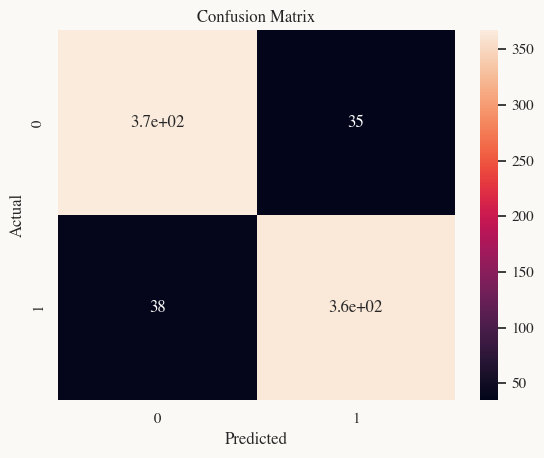

In [142]:
# Evaluate
print("Naive baseline accuracy: %.4f" % naive_baseline_accuracy)
print("=" * 10)
print("Training metrics:")
evaluate_model(logreg, X_train, y_train, plot=False)
print("=" * 10)
print("Test metrics:")
evaluate_model(logreg, X_test, y_test, plot=True);

Accuracy: 0.9104
Macro Acc: 0.9104
ROC-AUC: 0.9104


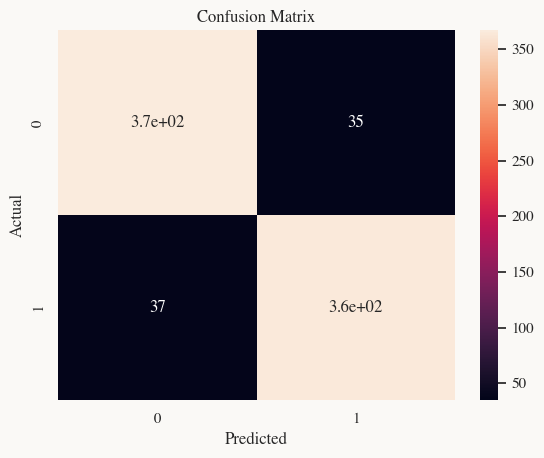

In [143]:
# sklearn model
logreg_skl = LogisticRegression()
logreg_skl.fit(X_train, y_train)
evaluate_model(logreg_skl, X_test, y_test);

##### Interpret Model

In [144]:
# Results
logreg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                passive   No. Observations:                 3214
Model:                          Logit   Df Residuals:                     3198
Method:                           MLE   Df Model:                           15
Date:                Fri, 01 May 2026   Pseudo R-squ.:                  0.6665
Time:                        16:26:03   Log-Likelihood:                -743.02
converged:                       True   LL-Null:                       -2227.8
Covariance Type:            nonrobust   LLR p-value:                     0.000
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -0.7629      0.146     -5.211      0.000      -1.050      -0.476
agent_len                   0.6729      0.098      6.864      0.000       0.481       0.865
agent_unigram_logprob      -0.0476      0.089     -0.534      0.594      -0.222       0.127
agent_is_pronoun           -2.4007      0.413     -5.817      0.000      -3.210      -1.592
agent_is_plural             0.2581      0.167      1.550      0.121      -0.068       0.585
agent_is_animate            0.1593      0.145      1.095      0.273      -0.126       0.444
agent_is_definite          -0.0767      0.152     -0.505      0.613      -0.374       0.221
patient_len                -0.3368      0.103     -3.282      0.001      -0.538      -0.136
patient_unigram_logprob     0.0806      0.080      1.007      0.314      -0.076       0.238
patient_is_pronoun          0.8186      0.353      2.320      0.020       0.127       1.510
patient_is_plural          -0.6185      0.176     -3.524      0.000      -0.962      -0.274
patient_is_animate          0.1997      0.214      0.931      0.352      -0.221       0.620
patient_is_definite         0.3103      0.149      2.078      0.038       0.018       0.603
uid_std                     0.1742      0.204      0.854      0.393      -0.225       0.574
uid_pwd                    -1.0096      0.223     -4.527      0.000      -1.447      -0.572
surp_slor                   6.4252      0.308     20.835      0.000       5.821       7.030
===========================================================================================
"""

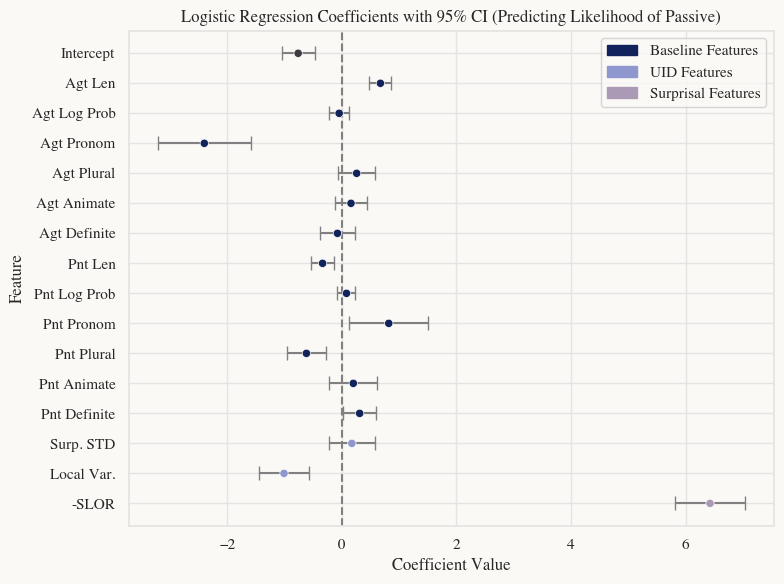

In [145]:
# Plots confidence intervals for coefficients from statsmodels
ci = logreg.conf_int()
ci.columns = ['2.5%', '97.5%']
ci['coef'] = logreg.params
ci = ci.reset_index().rename(columns={'index': 'feature'})
# ci = ci[ci['feature'] != 'Intercept']
fig = plt.figure(figsize=(8, 6))
sns.scatterplot(x=ci['coef'], y=ci['feature'], 
                hue=ci['feature'], palette=feature_cmap, zorder=20)
x_coords = np.arange(len(ci))
y_coords = ci['coef']
xerr = ci['coef'] - ci['2.5%']
plt.errorbar(x=y_coords, y=x_coords, xerr=xerr, fmt='none', ecolor='grey', capsize=5)
plt.axvline(0, color='grey', linestyle='--')
plt.title("Logistic Regression Coefficients with 95% CI (Predicting Likelihood of Passive)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
ticks = list(X.columns)
plt.yticks(
    ticks = ticks,
    labels = [format_map[tick] for tick in ticks] 
)
plt.tight_layout()
create_legend(feature_legend_cmap)
fig.savefig("../plots/modeling_logreg_coeffs" + plot_suffix,
            dpi=100, bbox_inches='tight', transparent=True)

In [146]:
pw_diffs.dtypes

doc_name                       str
sent_idx                   float64
context                        str
uid_std                    float64
uid_pwd                    float64
surp_slor                  float64
agent_len                  float64
agent_unigram_logprob      float64
agent_is_pronoun              bool
agent_is_plural               bool
agent_is_animate              bool
agent_is_definite             bool
patient_len                float64
patient_unigram_logprob    float64
patient_is_pronoun            bool
patient_is_plural             bool
patient_is_animate            bool
patient_is_definite           bool
conversion                     str
passive                       bool
dtype: object

<Axes: xlabel='uid_pwd', ylabel='surp_slor'>

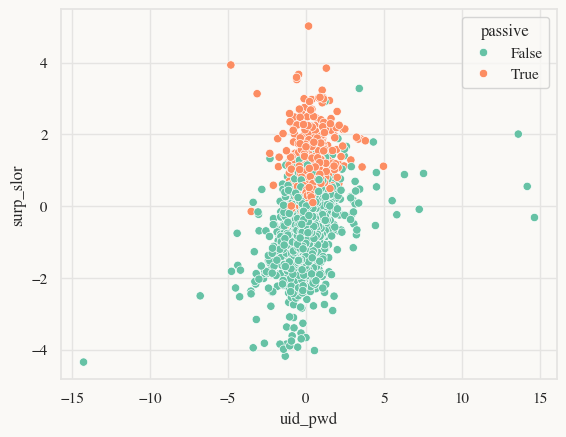

In [147]:
sns.scatterplot(pw_diffs, x='uid_pwd', y='surp_slor', hue='passive')

In [148]:
pw_diffs[uid_features + surp_features + ling_features].describe()

,uid_std,uid_pwd,surp_slor,agent_len,agent_unigram_logprob,patient_len,patient_unigram_logprob
count,12794.000000,12794.000000,12794.000000,12794.000000,12794.000000,12794.000000,12794.000000
mean,-0.026804,-0.011495,-0.216332,0.008766,-0.016169,-0.011334,0.005332
std,0.597404,0.546819,0.615040,1.021959,1.000104,0.954439,0.998789
min,-6.474990,-14.277314,-4.348021,-0.470004,-2.220523,-0.629661,-2.679702
25%,-0.233948,-0.169837,-0.517498,-0.470004,-0.771333,-0.507016,-0.617739
50%,-0.000030,-0.003059,-0.205011,-0.266921,-0.037021,-0.384371,0.069257
75%,0.186133,0.125631,0.021468,0.139245,0.698308,0.106211,0.667306
max,5.287243,14.639014,5.016045,64.719626,2.370521,35.305458,3.260582


In [149]:
(pw_diffs['uid_pwd']).median()

np.float64(-0.0030591994286809365)

In [150]:
pw_diffs.groupby('passive')[uid_features + surp_features].apply(lambda g: g.describe().loc[['mean', 'std']]).reset_index().sort_values("level_1")

,passive,level_1,uid_std,uid_pwd,surp_slor
0,False,mean,-0.102182,-0.044003,-0.366695
2,True,mean,0.377851,0.163019,0.590867
1,False,std,0.550436,0.544776,0.490905
3,True,std,0.672502,0.524396,0.585180


In [151]:
pw_diffs[pw_diffs['uid_pwd'] >= 5]

,doc_name,sent_idx,context,uid_std,uid_pwd,surp_slor,agent_len,agent_unigram_logprob,agent_is_pronoun,agent_is_plural,agent_is_animate,agent_is_definite,patient_len,patient_unigram_logprob,patient_is_pronoun,patient_is_plural,patient_is_animate,patient_is_definite,conversion,passive
3233,wik_eng_wikipedia_1.00911_x01135,8.0,document,1.237043,14.639014,-0.318578,-0.470004,1.353262,True,False,True,True,-0.384371,0.222547,False,False,False,False,A to P,False
3332,wik_eng_wikipedia_1.00936_x01163,2.0,document,0.204858,5.811956,-0.240901,-0.470004,1.541534,True,False,True,True,-0.139080,-0.171082,False,False,False,False,A to P,False
4239,wik_eng_wikipedia_1.01149_x01434,3.0,document,1.251244,7.249627,-0.089680,-0.470004,-1.719191,False,False,False,False,-0.139080,0.108325,False,True,False,False,A to P,False
4900,wik_eng_wikipedia_1.01352_x01680,6.0,document,0.781364,6.300513,0.877876,-0.470004,1.353262,True,False,True,True,0.106211,-2.355369,False,True,True,False,A to P,False
5433,wik_eng_wikipedia_1.01469_x01830,66.0,document,1.446078,13.601579,2.006494,-0.470004,-0.302665,False,True,False,False,-0.384371,-2.679702,False,False,False,False,A to P,False
6870,wik_eng_wikipedia_1.01901_x02395,5.0,document,-1.895665,5.514259,0.149539,-0.266921,0.417129,False,False,False,True,-0.507016,0.882906,False,False,False,False,A to P,False
7845,wik_eng_wikipedia_1.02163_x02737,14.0,document,2.796811,7.527838,0.909386,-0.266921,0.265424,False,False,False,False,-0.016434,-2.355369,False,False,True,False,A to P,False
9402,wik_eng_wikipedia_1.02540_x03194,8.0,document,5.287243,14.175039,0.548044,-0.470004,-1.086620,False,False,True,False,0.474148,0.330357,False,True,False,True,A to P,False


In [152]:
cf_comparison[(cf_comparison['doc_name'] == 'email-enronsent40_01') & (cf_comparison['sent_idx']==46)]

,doc_name,sent_idx,level_2,doc_id,context,Unnamed: 0,sentence,tokens,units,surp_mean,...,patient_len,patient_unigram_logprob,patient_is_pronoun,patient_is_plural,patient_is_animate,patient_is_definite,factual,conv_idx,conversion,passive


In [153]:
full_features = ([]
    + ling_features
    + uid_features
    # + surp_features
    )
feature_order = []
pos_neg = []

y_check = pw_diffs['passive']

for feature in full_features:
    if feature == 'uid_pwd':
        continue
    feature_order.append(feature)
    nminus1 = [ftr for ftr in full_features if ftr != feature]
    X_nminus1 = pw_diffs[nminus1]
    X_nminus1 = sm.add_constant(X_nminus1, has_constant='add')
    X_nminus1 = X_nminus1.astype(np.float64)
    lr = sm.Logit(y_check, X_nminus1).fit()
    ci = lr.conf_int().loc['uid_pwd']
    if ci[0] > 0:
        pos_neg.append('pos')
    elif ci[1] < 0:
        pos_neg.append('neg')
    else:
        pos_neg.append('neut')

Optimization terminated successfully.
         Current function value: 0.311785
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.276910
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.283984
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.276804
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.276701
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.276677
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.284462
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.276669
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.279875
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.276981
  

In [154]:
dict(zip(feature_order, pos_neg))

{'agent_len': 'neut',
 'agent_unigram_logprob': 'neut',
 'agent_is_pronoun': 'neut',
 'agent_is_plural': 'neut',
 'agent_is_animate': 'neut',
 'agent_is_definite': 'neut',
 'patient_len': 'neut',
 'patient_unigram_logprob': 'neut',
 'patient_is_pronoun': 'neut',
 'patient_is_plural': 'neut',
 'patient_is_animate': 'neut',
 'patient_is_definite': 'neut',
 'uid_std': 'pos'}

*Ceteris paribus plots*

In [155]:
X.shape

(4018, 16)

In [156]:
cp_features_list = ['agent_len', 'uid_std', 'uid_pwd', 'surp_slor']
lr_cp_plots = dict()
for feature in tqdm(cp_features_list, desc="Calculating Cet. Par. Plots..."):
    X_sample = X.sample(6000, replace=True)
    value, proba = cp_plot(X_sample, feature, logreg_skl, grid_size=100)
    lr_cp_plots[feature] = pd.DataFrame({
        'value': value,
        'proba': proba
    })

Calculating Cet. Par. Plots...: 100%|██████████| 4/4 [02:04<00:00, 31.19s/it]


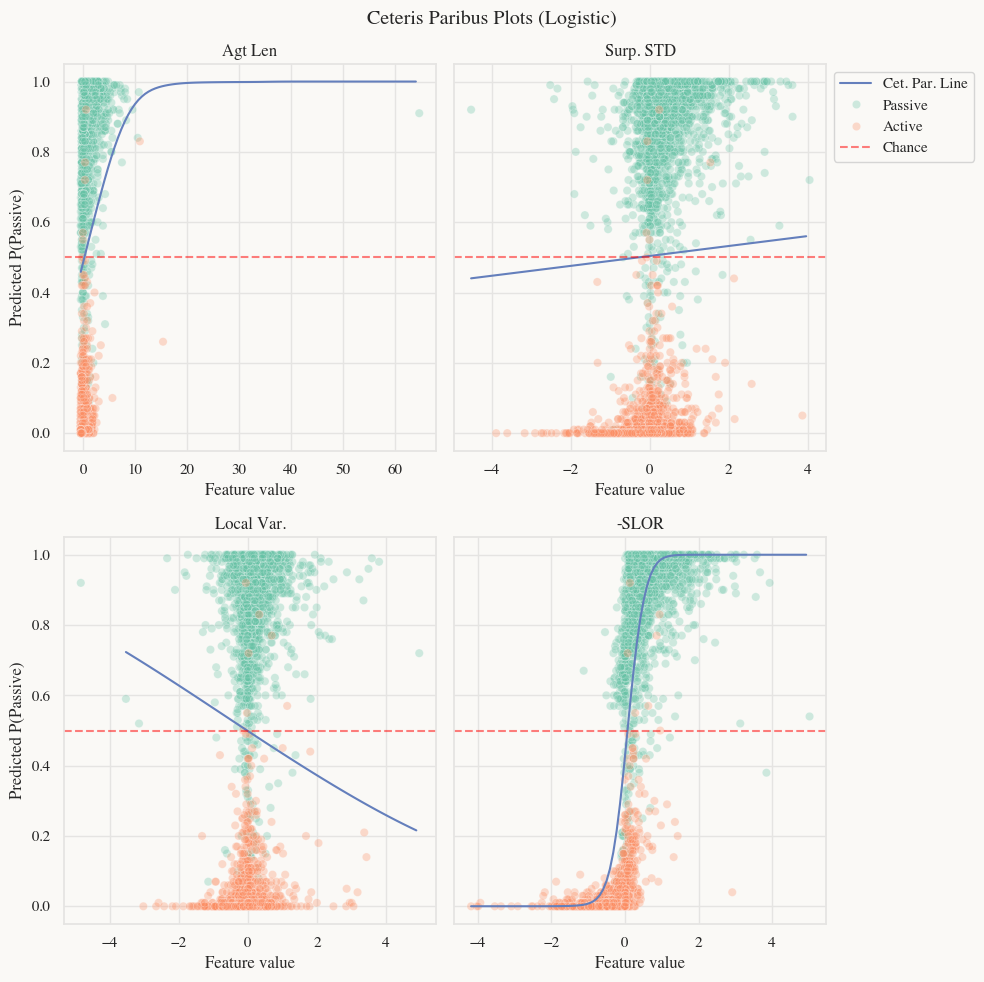

In [157]:
n_cols = 2
n_rows = np.ceil(len(cp_features_list) / n_cols).astype(int)
fig, axs = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows),
                        sharey=True)
observations = X.copy(deep=True)
observations['pred_proba'] = rf.predict_proba(observations)[:, 1]
observations['og_form'] = ["Passive" if y_val == 1 else "Active" for y_val in y]
axs = np.array(axs).ravel()
for i, pair in enumerate(lr_cp_plots.items()):
    feat_name, data = pair
    sns.lineplot(data, x='value', y='proba', ax=axs[i],
                 label='Cet. Par. Line', color='#647FBC')
    sns.scatterplot(observations, x=feat_name, y='pred_proba',
                    hue='og_form',
                    ax=axs[i], alpha=0.3)
    axs[i].set_title(format_map[feat_name])
    axs[i].set_ylabel('Predicted P(Passive)')
    axs[i].set_xlabel('Feature value')
    axs[i].axhline(y=y.mean(), color='red', linestyle='--', alpha=0.5, label='Chance')
    if i == n_cols - 1:
        axs[i].legend(bbox_to_anchor=(1, 1))
    else:
        axs[i].get_legend().remove()
fig.suptitle("Ceteris Paribus Plots (Logistic)")
fig.tight_layout()

#### Random Forest Model

In [158]:
n_trials = 10
results = {
    'Feature': [],
    'Importance': []
}
for _ in tqdm(range(n_trials)):
    rf = RandomForestClassifier(n_estimators=100)
    rf.fit(X_train, y_train)
    results['Feature'].extend(X.columns)
    results['Importance'].extend(rf.feature_importances_)
results = pd.DataFrame(results)

100%|██████████| 10/10 [00:02<00:00,  4.76it/s]


Naive baseline accuracy: 0.50
Training metrics:
Accuracy: 1.0000
Macro Acc: 1.0000
ROC-AUC: 1.0000
Test metrics:
Accuracy: 0.9241
Macro Acc: 0.9241
ROC-AUC: 0.9241


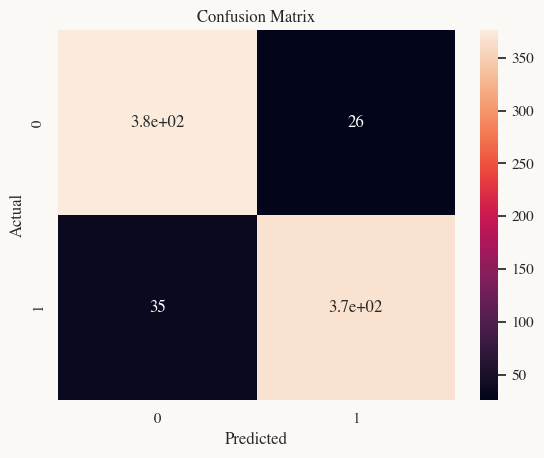

In [159]:
# Evaluate
print("Naive baseline accuracy: %.2f" % naive_baseline_accuracy)
print("=" * 10)
print("Training metrics:")
evaluate_model(rf, X_train, y_train, plot=False)
print("=" * 10)
print("Test metrics:")
evaluate_model(rf, X_test, y_test, plot=True);

##### Interpret Model

*Importance Plot*

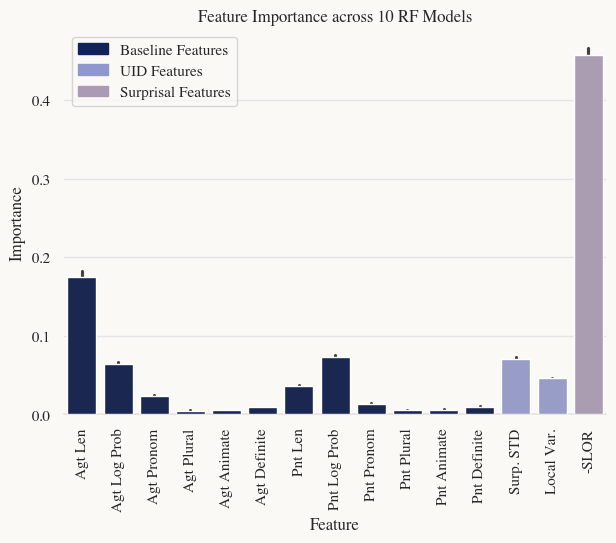

In [160]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(results[results['Feature'] != 'const'], x='Feature', y='Importance',
            errorbar=('ci', 95), 
            hue='Feature', palette=feature_cmap,
            zorder=20)
ticks = list(X.columns)
ticks.remove('const')
plt.xticks(
    ticks = ticks,
    labels = [format_map[tick] for tick in ticks],
    rotation=90)
plt.grid(axis='y', zorder=-1)
for spine in ['left', 'top', 'right']:
    ax.spines[spine].set_visible(False)
create_legend(feature_legend_cmap)
plt.title(f"Feature Importance across {n_trials} RF Models");

*Ceteris Paribus Plots*

In [161]:
cp_features_list = ['agent_len', 'uid_std', 'uid_pwd', 'surp_slor']
rf_cp_plots = dict()
for feature in tqdm(cp_features_list, desc="Calculating Cet. Par. Plots..."):
    X_sample = X.sample(6000, replace=True)
    value, proba = cp_plot(X_sample, feature, rf, grid_size=100)
    rf_cp_plots[feature] = pd.DataFrame({
        'value': value,
        'proba': proba
    })

Calculating Cet. Par. Plots...: 100%|██████████| 4/4 [03:25<00:00, 51.27s/it]


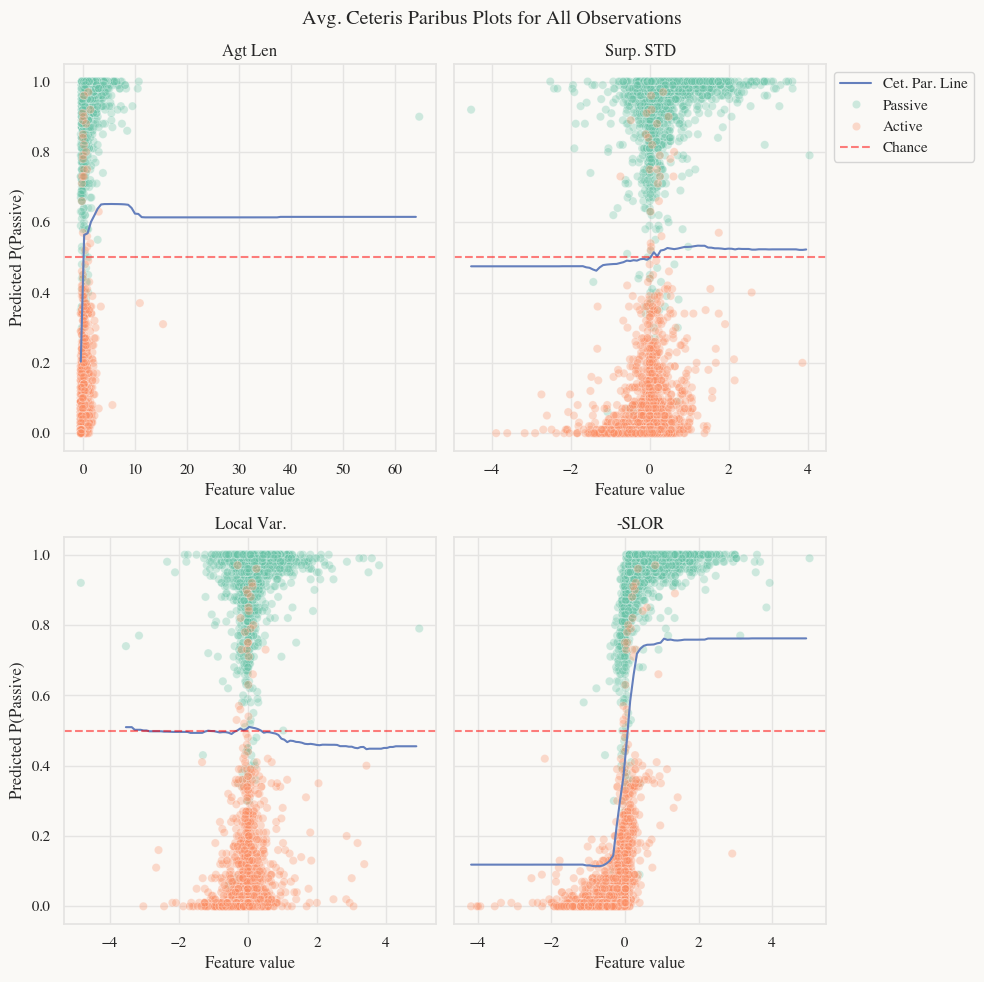

In [162]:
n_cols = 2
n_rows = np.ceil(len(cp_features_list) / n_cols).astype(int)
fig, axs = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows),
                        sharey=True)
observations = X.copy(deep=True)
observations['pred_proba'] = rf.predict_proba(observations)[:, 1]
observations['og_form'] = ["Passive" if y_val == 1 else "Active" for y_val in y]
axs = np.array(axs).ravel()
for i, pair in enumerate(rf_cp_plots.items()):
    feat_name, data = pair
    sns.lineplot(data, x='value', y='proba', ax=axs[i],
                 label='Cet. Par. Line', color='#647FBC')
    sns.scatterplot(observations, x=feat_name, y='pred_proba',
                    hue='og_form',
                    ax=axs[i], alpha=0.3)
    axs[i].set_title(format_map[feat_name])
    axs[i].set_ylabel('Predicted P(Passive)')
    axs[i].set_xlabel('Feature value')
    axs[i].axhline(y=y.mean(), color='red', linestyle='--', alpha=0.5, label='Chance')
    if i == n_cols - 1:
        axs[i].legend(bbox_to_anchor=(1, 1))
    else:
        axs[i].get_legend().remove()
fig.suptitle("Avg. Ceteris Paribus Plots for All Observations")
fig.tight_layout()

<Axes: xlabel='pred_proba', ylabel='Count'>

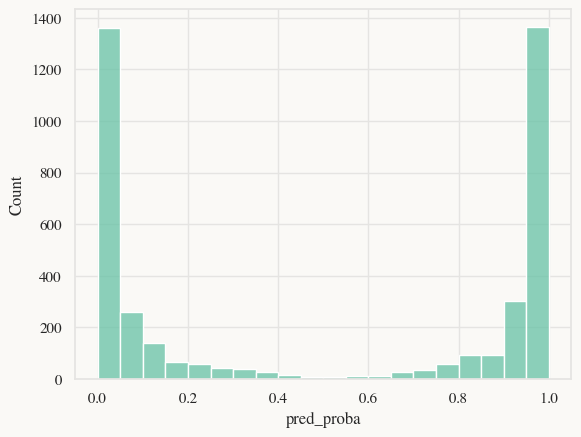

In [163]:
sns.histplot(observations['pred_proba'], bins=20)